# ДЗ №5. TIGER-like архитектура для рекомендаций

Общая информация  

Дата выдачи: 25 мая 2026

Дедлайн: 10 июня 2026 23:59 MSK


В этом задании мы соберем упрощенный generative retrieval pipeline по мотивам [**TIGER**](https://proceedings.neurips.cc/paper_files/paper/2023/file/20dcab0f14046a5c6b02b61da9f13229-Paper-Conference.pdf):

1. Возьмем датасет **KION**.
2. Построим для айтемов **semantic ids** через **RQ-VAE**.
3. Поверх semantic ids обучим **tiger-like** next-token recommender.
4. Посчитаем метрики на **настоящих `item_id`**, а не на токенах semantic id.
5. Сравним результат с `MostPop` и `SASRec-like` baseline.
6. Отдельно проверим, что происходит, если semantic id обучаются **без уникализирующего suffix/id**, а затем декодируются обратно в item разными способами.

В отличие от классических retrieval-моделей, здесь модель не ранжирует весь каталог напрямую, а **генерирует код следующего айтема**. Поэтому в этом ДЗ важно аккуратно разделять:

- качество самих semantic ids;
- качество generative модели по semantic ids;
- качество итоговых рекомендаций после обратного декодинга в реальные `item_id`.


В этом задании следующая разбалловка:

1. Обучение и анализ semantic ids через `RQ-VAE` - **3 балла**
2. Обучение `tiger-like` next-token модели - **3 балла**
3. Сравнение с `MostPop` и `SASRec-like` - **2 балла**
4. Эксперимент с неуникальными semantic ids и разными стратегиями декодинга - **2 балла**

Соответственно, максимум можно набрать **10 баллов**.


## Короткая теория

### 1. Semantic IDs

Проблема обычных `item_id` в том, что они, как правило, **не несут семантики**: два похожих фильма имеют совершенно независимые идентификаторы.  
Идея semantic ids состоит в том, чтобы сопоставить каждому айтему **короткую дискретную последовательность токенов**, где близкие по смыслу айтемы имеют похожие коды.

Для этого удобно взять фиксированные item-embeddings по контенту и затем **квантовать** их через `RQ-VAE`:

- encoder переводит эмбеддинг в другое скрытое представление;
- residual quantization по нескольким codebook-уровням превращает в последовательность дискретных кодов;
- decoder пытается восстановить исходный embedding;
- дополнительные регуляризаторы позволяют контролировать загрузку codebook-ов, коллизии и энтропию.

### 2. TIGER-like generative retrieval

В статье TIGER recommendation рассматривается как **autoregressive generation** semantic id следующего айтема.  
История пользователя кодируется как последовательность токенов прошлых semantic ids, а модель предсказывает токены следующего айтема.

Упрощенно это выглядит так:

- у айтема есть semantic id, например `[c1, c2, c3, c4]`;
- история пользователя превращается в длинную token-sequence;
- decoder-only Transformer предсказывает следующий токен;
- после генерации semantic id он декодируется обратно в реальный `item_id`.

### 3. Зачем нужен уникализирующий suffix

Если несколько айтемов попадают в один и тот же semantic bucket, возникает **коллизия**.  
Один способ справиться с этим - добавить к semantic id дополнительный уникализирующий suffix.  
Другой путь - оставить id чисто семантическим, а потом восстанавливать `item_id` через отдельный mapping внутри bucket-а. Именно это вы исследуете в последней части ДЗ.


[Ссылка](https://proceedings.neurips.cc/paper_files/paper/2023/file/20dcab0f14046a5c6b02b61da9f13229-Paper-Conference.pdf) на работу по Semantic-ids и TIGER: 




In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn torch tqdm sentencepiece


In [1]:
import math
import random
import warnings
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")


/Users/maksimlunin/Desktop/jupyter/Рекомендательные системы/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. Загрузка данных

Работаем с KION-датасетом из соревнования:

https://ods.ai/competitions/competition-recsys-21/data

Нужны файлы:

- `interactions.csv`
- `items.csv`
- `users.csv`

Ноутбук ищет их рядом с собой, уровнем выше или на два уровня выше.


In [2]:
def find_file(candidates: List[str]) -> Optional[Path]:
    search_roots = [Path("."), Path(".."), Path("../.."), Path("/mnt/data")]
    for root in search_roots:
        for name in candidates:
            path = root / name
            if path.exists():
                return path.resolve()
    return None


interactions_path = find_file(["interactions.csv", "kion_interactions.csv"])
items_path = find_file(["items.csv", "kion_items.csv"])
users_path = find_file(["users.csv", "kion_users.csv"])

print("interactions_path =", interactions_path)
print("items_path        =", items_path)
print("users_path        =", users_path)


interactions_path = /Users/maksimlunin/Desktop/jupyter/Рекомендательные системы/interactions.csv
items_path        = /Users/maksimlunin/Desktop/jupyter/Рекомендательные системы/items.csv
users_path        = /Users/maksimlunin/Desktop/jupyter/Рекомендательные системы/users.csv


In [3]:
assert interactions_path is not None, "Не найден interactions.csv"
assert items_path is not None, "Не найден items.csv"
assert users_path is not None, "Не найден users.csv"

interactions = pd.read_csv(interactions_path)
items = pd.read_csv(items_path)
users = pd.read_csv(users_path)

print(interactions.shape, items.shape, users.shape)
interactions.head()


(5476251, 5) (15963, 14) (840197, 5)


,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


## 1. Подготовка выборки

Чтобы не делать ДЗ неподъемным, возьмем **сэмпл активных пользователей и популярных айтемов**.  
При желании вы можете изменить размеры выборки, но в отчете обязательно укажите, какой сэмпл использовали.


In [4]:
RANDOM_STATE = 42
SAMPLE_USERS = 15000
SAMPLE_ITEMS = 20000
MIN_USER_INTERACTIONS = 5
MAX_SEQ_LEN = 50
TOP_K = 10

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

TARGET_COL = "item_id"
USER_COL = "user_id"
TIME_COL = "last_watch_dt" if "last_watch_dt" in interactions.columns else "watched_pct"


In [5]:
interactions = interactions.copy()

if "last_watch_dt" in interactions.columns:
    interactions["last_watch_dt"] = pd.to_datetime(interactions["last_watch_dt"])
    sort_cols = [USER_COL, "last_watch_dt"]
else:
    sort_cols = [USER_COL]

if "total_dur" in interactions.columns:
    interactions["total_dur"] = interactions["total_dur"].fillna(0)

user_activity = interactions[USER_COL].value_counts()
item_popularity = interactions[TARGET_COL].value_counts()

selected_users = user_activity.head(SAMPLE_USERS).index
selected_items = item_popularity.head(SAMPLE_ITEMS).index

df = interactions[
    interactions[USER_COL].isin(selected_users) &
    interactions[TARGET_COL].isin(selected_items)
].copy()

df = df.sort_values(sort_cols).reset_index(drop=True)
df = df[df.groupby(USER_COL)[TARGET_COL].transform("size") >= MIN_USER_INTERACTIONS].copy()

print(df.shape)
df.head()


(995585, 5)


,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,2,7571,2021-05-20,6151,100.0
1,2,11577,2021-05-21,4974,98.0
2,2,16166,2021-05-21,5980,95.0
3,2,8936,2021-05-29,18,1.0
4,2,4436,2021-05-29,2618,30.0


Сделайте split по пользователям в стиле leave-last-out:

- `train`: вся история кроме двух последних событий пользователя;
- `valid`: предпоследний айтем;
- `test`: последний айтем.

Если хотите, можете использовать другой аккуратный temporal split, но тогда явно опишите его в отчете.


In [6]:
def leave_last_two_out(data: pd.DataFrame, user_col: str, item_col: str, sort_cols: List[str]):
    data = data.sort_values(sort_cols).copy()
    data["_row_num"] = data.groupby(user_col).cumcount()
    data["_user_len"] = data.groupby(user_col)[item_col].transform("size")

    train = data[data["_row_num"] < data["_user_len"] - 2].copy()
    valid = data[data["_row_num"] == data["_user_len"] - 2].copy()
    test = data[data["_row_num"] == data["_user_len"] - 1].copy()

    return (
        train.drop(columns=["_row_num", "_user_len"]),
        valid.drop(columns=["_row_num", "_user_len"]),
        test.drop(columns=["_row_num", "_user_len"]),
    )


train_df, valid_df, test_df = leave_last_two_out(df, USER_COL, TARGET_COL, sort_cols)

print(train_df.shape, valid_df.shape, test_df.shape)


(965585, 5) (15000, 5) (15000, 5)


In [7]:
train_sequences = (
    train_df
    .sort_values(sort_cols)
    .groupby(USER_COL)[TARGET_COL]
    .apply(list)
    .to_dict()
)

valid_targets = dict(zip(valid_df[USER_COL], valid_df[TARGET_COL]))
test_targets = dict(zip(test_df[USER_COL], test_df[TARGET_COL]))

eval_users = sorted(set(test_targets) & set(train_sequences))
len(eval_users)


15000

## 2. Метрики

Мы сравниваем модели уже на **реальных item_id**.  
Реализуйте (или переиспользуйте реализации из предыдущих ДЗ) как минимум:

- `Recall@K`
- `NDCG@K`
- `MRR@K`

Можно дополнительно посчитать `HitRate@K`, `Coverage@K`, `Novelty@K`.


In [8]:
def recall_at_k(recs: Dict[int, List[int]], target: Dict[int, int], k: int = 10) -> float:
    hits = sum(
        target[u] in recs.get(u, [])[:k]
        for u in target
        if u in recs
    )
    return hits / len(target)


def ndcg_at_k(recs: Dict[int, List[int]], target: Dict[int, int], k: int = 10) -> float:
    score = 0.0

    for u, gt in target.items():
        pred = recs.get(u, [])[:k]

        if gt in pred:
            rank = pred.index(gt) + 1
            score += 1.0 / np.log2(rank + 1)

    return score / len(target)


def mrr_at_k(recs: Dict[int, List[int]], target: Dict[int, int], k: int = 10) -> float:
    score = 0.0

    for u, gt in target.items():
        pred = recs.get(u, [])[:k]

        if gt in pred:
            rank = pred.index(gt) + 1
            score += 1.0 / rank

    return score / len(target)


def evaluate_recommendations(recs: Dict[int, List[int]], target: Dict[int, int], k: int = 10) -> pd.DataFrame:
    return pd.DataFrame(
        {
            f"Recall@{k}": [recall_at_k(recs, target, k)],
            f"NDCG@{k}": [ndcg_at_k(recs, target, k)],
            f"MRR@{k}": [mrr_at_k(recs, target, k)],
        },
        index=["score"],
    )


## I. Semantic IDs через RQ-VAE (3 балла)

В этой части нужно:

1. Построить фиксированные item-embeddings по метаданным айтемов.
2. Обучить `RQ-VAE`, получив многотокенный semantic id.
3. Посчитать и визуализировать метрики качества semantic ids.

Обязательно покажите графики обучения хотя бы по:

- reconstruction loss;
- доле коллизий;
- энтропии использования кодов;
- average bucket size или effective codebook usage.

Дополнительно приветствуются:

- доля неиспользуемых кодов;

Реализацию вы можете взять отсюда [https://github.com/EdoardoBotta/RQ-VAE-Recommender](https://github.com/EdoardoBotta/RQ-VAE-Recommender)


Для простоты можно собрать content features из `title`, `genres`, `countries`, `release_year`, других доступных полей.  
Необязательно делать сильный content encoder: в этой работе главное не качество текстовой модели, а корректный пайплайн `semantic ids -> generative retrieval`.

Ниже используется TF-IDF, но вы можете заменить эмбеддер на любую хорошую языковую модель


In [9]:
def split_tokens(x) -> List[str]:
    if pd.isna(x):
        return []
    text = str(x)
    for sep in [",", "|", "/"]:
        if sep in text:
            return [part.strip() for part in text.split(sep) if part.strip()]
    return [text.strip()] if text.strip() else []


items_work = items[items[TARGET_COL].isin(pd.Index(df[TARGET_COL].unique()))].copy()
items_work["title"] = items_work.get("title", pd.Series("", index=items_work.index)).fillna("")
items_work["genres_text"] = items_work.get("genres", pd.Series("", index=items_work.index)).fillna("")
items_work["countries_text"] = items_work.get("countries", pd.Series("", index=items_work.index)).fillna("")
items_work["release_year_num"] = pd.to_numeric(
    items_work.get("release_year", pd.Series(np.nan, index=items_work.index)),
    errors="coerce",
).fillna(0)

items_work["content_text"] = (
    items_work["title"].astype(str) + " " +
    items_work["genres_text"].astype(str) + " " +
    items_work["countries_text"].astype(str)
)

items_work = items_work.drop_duplicates(subset=[TARGET_COL]).reset_index(drop=True)
items_work.head()


,item_id,content_type,title,title_orig,release_year,genres,countries,for_kids,age_rating,studios,directors,actors,description,keywords,genres_text,countries_text,release_year_num,content_text
0,10711,film,Поговори с ней,Hable con ella,2002.0,"драмы, зарубежные, детективы, мелодрамы",Испания,NaN,16.0,NaN,Педро Альмодовар,"Адольфо Фернандес, Ана Фернандес, Дарио Гранди...",Мелодрама легендарного Педро Альмодовара «Пого...,"Поговори, ней, 2002, Испания, друзья, любовь, ...","драмы, зарубежные, детективы, мелодрамы",Испания,2002.0,"Поговори с ней драмы, зарубежные, детективы, м..."
1,2508,film,Голые перцы,Search Party,2014.0,"зарубежные, приключения, комедии",США,NaN,16.0,NaN,Скот Армстронг,"Адам Палли, Брайан Хаски, Дж.Б. Смув, Джейсон ...",Уморительная современная комедия на популярную...,"Голые, перцы, 2014, США, друзья, свадьбы, прео...","зарубежные, приключения, комедии",США,2014.0,"Голые перцы зарубежные, приключения, комедии США"
2,10716,film,Тактическая сила,Tactical Force,2011.0,"криминал, зарубежные, триллеры, боевики, комедии",Канада,NaN,16.0,NaN,Адам П. Калтраро,"Адриан Холмс, Даррен Шалави, Джерри Вассерман,...",Профессиональный рестлер Стив Остин («Все или ...,"Тактическая, сила, 2011, Канада, бандиты, ганг...","криминал, зарубежные, триллеры, боевики, комедии",Канада,2011.0,"Тактическая сила криминал, зарубежные, триллер..."
3,7868,film,45 лет,45 Years,2015.0,"драмы, зарубежные, мелодрамы",Великобритания,NaN,16.0,NaN,Эндрю Хэй,"Александра Риддлстон-Барретт, Джеральдин Джейм...","Шарлотта Рэмплинг, Том Кортни, Джеральдин Джей...","45, лет, 2015, Великобритания, брак, жизнь, лю...","драмы, зарубежные, мелодрамы",Великобритания,2015.0,"45 лет драмы, зарубежные, мелодрамы Великобрит..."
4,1468,film,Марья-искусница,NaN,1960.0,"фильмы, сказки, приключения, советские, семейн...",СССР,NaN,6.0,NaN,Александр Роу,"Александр Баранов, Александр Хвыля, Анатолий К...",Два прославленных советских сказочника – писат...,"Марья-искусница, 1960, СССР, преодоление, труд...","фильмы, сказки, приключения, советские, семейн...",СССР,1960.0,"Марья-искусница фильмы, сказки, приключения, с..."


In [10]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
text_features = vectorizer.fit_transform(items_work["content_text"])

svd = TruncatedSVD(n_components=128, random_state=RANDOM_STATE)
text_dense = svd.fit_transform(text_features)

num_features = items_work[["release_year_num"]].to_numpy(dtype=np.float32)
num_features = StandardScaler().fit_transform(num_features)

item_content_matrix = np.concatenate([text_dense, num_features], axis=1).astype(np.float32)
item_ids = items_work[TARGET_COL].tolist()

print(item_content_matrix.shape)


(13919, 129)


In [11]:
@dataclass
class RQVAEConfig:
    input_dim: int
    hidden_dim: int = 256
    latent_dim: int = 64
    num_codebooks: int = 4
    codebook_size: int = 64
    commitment_weight: float = 0.25
    entropy_weight: float = 0.0


class RQVAE(nn.Module):
    def __init__(self, config: RQVAEConfig):
        super().__init__()
        self.config = config

        self.encoder = nn.Sequential(
            nn.Linear(config.input_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(config.latent_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.input_dim),
        )

        self.codebooks = nn.ParameterList(
            [
                nn.Parameter(
                    torch.randn(config.codebook_size, config.latent_dim) * 0.02
                )
                for _ in range(config.num_codebooks)
            ]
        )

    def encode(self, x: torch.Tensor):
        return self.encoder(x)

    def quantize(self, z_e: torch.Tensor):
        residual = z_e
        quantized_sum = torch.zeros_like(z_e)

        all_indices = []
        commitment_loss = 0.0

        for codebook in self.codebooks:
            distances = (
                residual.pow(2).sum(dim=1, keepdim=True)
                - 2 * residual @ codebook.t()
                + codebook.pow(2).sum(dim=1)
            )

            indices = distances.argmin(dim=1)
            z_q = codebook[indices]

            commitment_loss = commitment_loss + F.mse_loss(
                residual, z_q.detach()
            )

            quantized_sum = quantized_sum + z_q
            residual = residual - z_q

            all_indices.append(indices)

        z_q_st = z_e + (quantized_sum - z_e).detach()

        codes = torch.stack(all_indices, dim=1)

        return z_q_st, codes, commitment_loss

    def decode(self, z_q: torch.Tensor):
        return self.decoder(z_q)

    def forward(self, x: torch.Tensor):
        z_e = self.encode(x)

        z_q, codes, commitment_loss = self.quantize(z_e)

        reconstruction = self.decode(z_q)

        recon_loss = F.mse_loss(reconstruction, x)

        loss = (
            recon_loss
            + self.config.commitment_weight * commitment_loss
        )

        return {
            "loss": loss,
            "recon_loss": recon_loss,
            "commitment_loss": commitment_loss,
            "reconstruction": reconstruction,
            "codes": codes,
            "z_e": z_e,
            "z_q": z_q,
        }


In [12]:
def semantic_collision_rate(codes: np.ndarray) -> float:
    unique_codes = {tuple(row.tolist()) for row in codes}
    return 1.0 - len(unique_codes) / len(codes)


def average_bucket_size(codes: np.ndarray) -> float:
    buckets = Counter(map(tuple, codes.tolist()))
    return float(np.mean(list(buckets.values())))


def codebook_entropy(codes_2d: np.ndarray, codebook_size: int) -> List[float]:
    entropies = []
    for level in range(codes_2d.shape[1]):
        counts = np.bincount(codes_2d[:, level], minlength=codebook_size).astype(np.float64)
        probs = counts / counts.sum()
        probs = probs[probs > 0]
        entropies.append(float(-(probs * np.log(probs + 1e-12)).sum()))
    return entropies


In [13]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE


'cpu'

In [14]:
rq_config = RQVAEConfig(input_dim=item_content_matrix.shape[1])
rqvae = RQVAE(rq_config).to(DEVICE)

tensor_data = torch.tensor(item_content_matrix, dtype=torch.float32)
train_loader = torch.utils.data.DataLoader(
    tensor_data,
    batch_size=256,
    shuffle=True,
)

optimizer = torch.optim.Adam(rqvae.parameters(), lr=1e-3)

num_epochs = 20

history = {
    "loss": [],
    "recon_loss": [],
    "commitment_loss": [],
    "collision_rate": [],
    "avg_bucket_size": [],
    "entropy": [],
}

for epoch in range(num_epochs):
    rqvae.train()

    epoch_loss = 0.0
    epoch_recon = 0.0
    epoch_commit = 0.0

    for batch in train_loader:
        batch = batch.to(DEVICE)

        out = rqvae(batch)

        optimizer.zero_grad()
        out["loss"].backward()
        optimizer.step()

        epoch_loss += out["loss"].item()
        epoch_recon += out["recon_loss"].item()
        epoch_commit += out["commitment_loss"].item()

    rqvae.eval()

    with torch.no_grad():
        full_x = tensor_data.to(DEVICE)
        full_out = rqvae(full_x)
        codes = full_out["codes"].cpu().numpy()

    history["loss"].append(epoch_loss / len(train_loader))
    history["recon_loss"].append(epoch_recon / len(train_loader))
    history["commitment_loss"].append(epoch_commit / len(train_loader))

    history["collision_rate"].append(
        semantic_collision_rate(codes)
    )

    history["avg_bucket_size"].append(
        average_bucket_size(codes)
    )

    history["entropy"].append(
        np.mean(
            codebook_entropy(
                codes,
                rq_config.codebook_size,
            )
        )
    )

    print(
        f"Epoch {epoch+1:02d} | "
        f"loss={history['loss'][-1]:.4f} | "
        f"recon={history['recon_loss'][-1]:.4f} | "
        f"commit={history['commitment_loss'][-1]:.4f} | "
        f"coll={history['collision_rate'][-1]:.4f}"
    )

Epoch 01 | loss=0.0113 | recon=0.0102 | commit=0.0044 | coll=0.9980
Epoch 02 | loss=0.0182 | recon=0.0059 | commit=0.0494 | coll=0.9966
Epoch 03 | loss=0.0034 | recon=0.0029 | commit=0.0020 | coll=0.9948
Epoch 04 | loss=0.0030 | recon=0.0027 | commit=0.0011 | coll=0.9948
Epoch 05 | loss=0.0030 | recon=0.0026 | commit=0.0013 | coll=0.9958
Epoch 06 | loss=0.0028 | recon=0.0025 | commit=0.0013 | coll=0.9915
Epoch 07 | loss=0.0030 | recon=0.0025 | commit=0.0016 | coll=0.9955
Epoch 08 | loss=0.0030 | recon=0.0025 | commit=0.0018 | coll=0.9957
Epoch 09 | loss=0.0028 | recon=0.0024 | commit=0.0017 | coll=0.9922
Epoch 10 | loss=0.0030 | recon=0.0025 | commit=0.0022 | coll=0.9944
Epoch 11 | loss=0.0029 | recon=0.0024 | commit=0.0023 | coll=0.9920
Epoch 12 | loss=0.0030 | recon=0.0023 | commit=0.0027 | coll=0.9942
Epoch 13 | loss=0.0031 | recon=0.0023 | commit=0.0029 | coll=0.9936
Epoch 14 | loss=0.0029 | recon=0.0023 | commit=0.0027 | coll=0.9897
Epoch 15 | loss=0.0032 | recon=0.0023 | commit=0

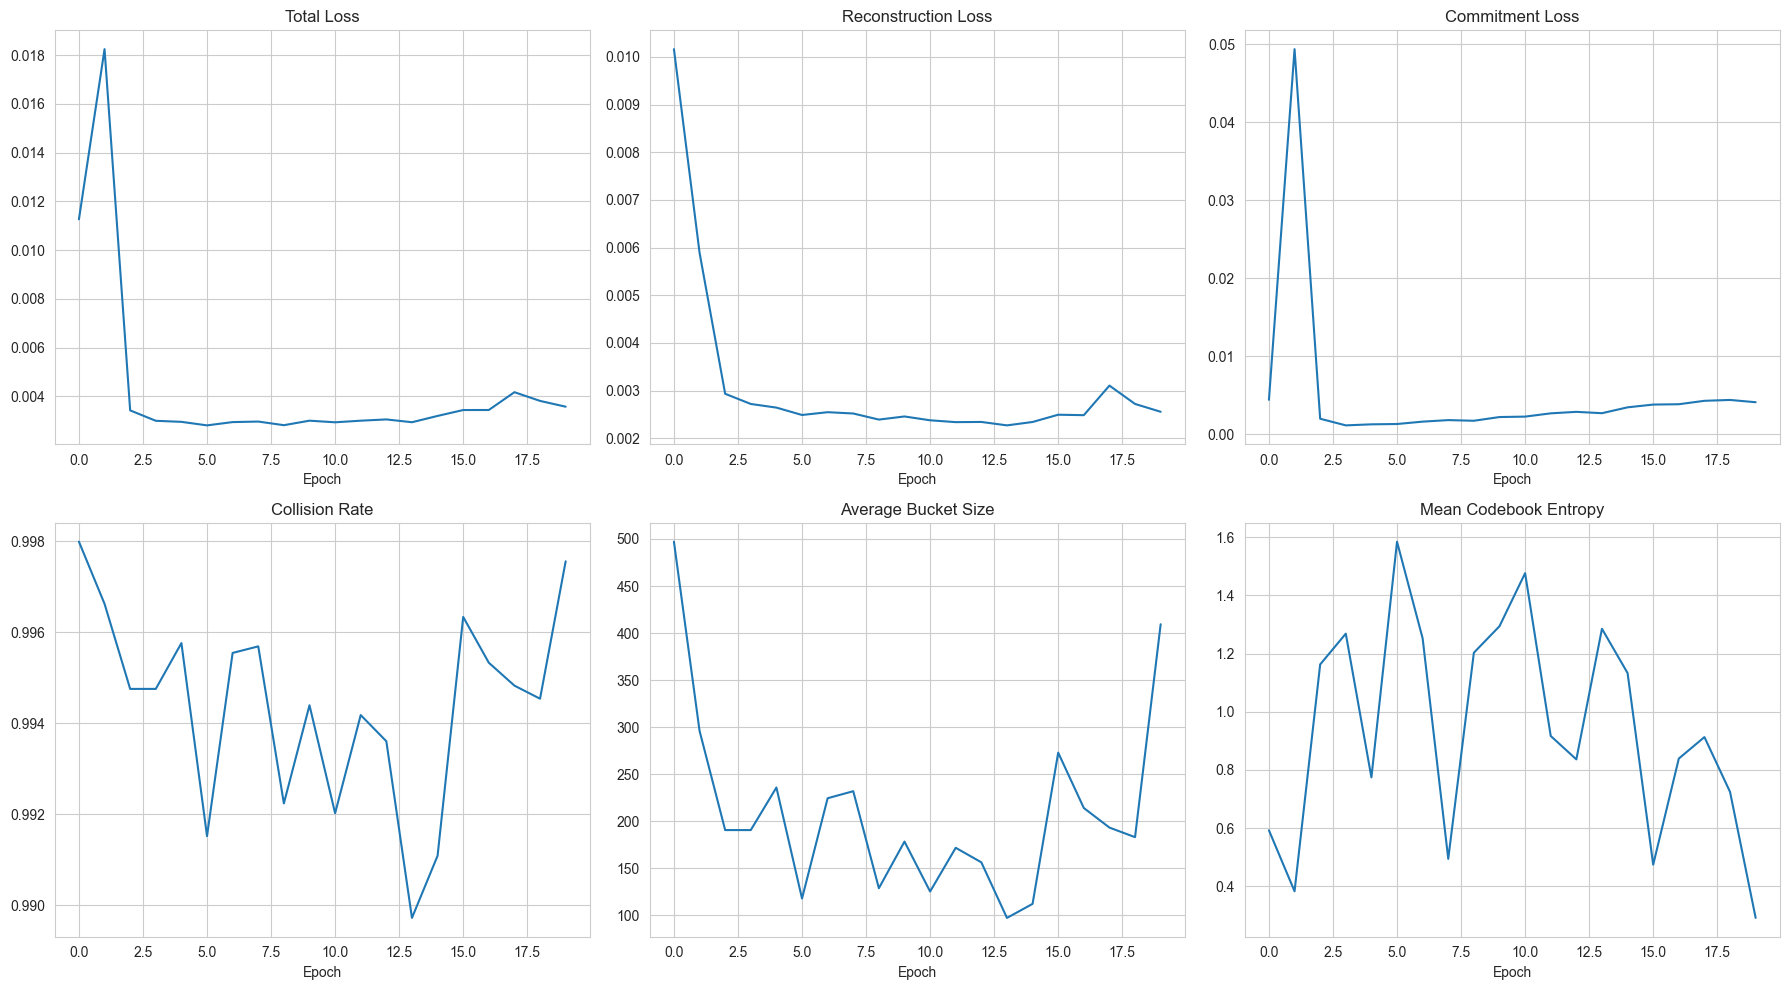

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].plot(history["loss"])
axes[0, 0].set_title("Total Loss")
axes[0, 0].set_xlabel("Epoch")

axes[0, 1].plot(history["recon_loss"])
axes[0, 1].set_title("Reconstruction Loss")
axes[0, 1].set_xlabel("Epoch")

axes[0, 2].plot(history["commitment_loss"])
axes[0, 2].set_title("Commitment Loss")
axes[0, 2].set_xlabel("Epoch")

axes[1, 0].plot(history["collision_rate"])
axes[1, 0].set_title("Collision Rate")
axes[1, 0].set_xlabel("Epoch")

axes[1, 1].plot(history["avg_bucket_size"])
axes[1, 1].set_title("Average Bucket Size")
axes[1, 1].set_xlabel("Epoch")

axes[1, 2].plot(history["entropy"])
axes[1, 2].set_title("Mean Codebook Entropy")
axes[1, 2].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

In [16]:
rqvae.eval()

with torch.no_grad():
    all_x = torch.tensor(
        item_content_matrix,
        dtype=torch.float32,
        device=DEVICE,
    )

    codes = rqvae(all_x)["codes"].cpu().numpy()

semantic_tokens = [tuple(row.tolist()) for row in codes]

bucket_counter = Counter(semantic_tokens)

semantic_tokens_unique = [
    code + (bucket_counter[code],)
    for code in semantic_tokens
]

item_semantic_df = pd.DataFrame(
    {
        "item_id": item_ids,
        "semantic_tokens": semantic_tokens,
        "semantic_tokens_unique": semantic_tokens_unique,
    }
)

item_semantic_df.head()


,item_id,semantic_tokens,semantic_tokens_unique
0,10711,"(27, 31, 59, 44)","(27, 31, 59, 44, 11408)"
1,2508,"(27, 31, 59, 44)","(27, 31, 59, 44, 11408)"
2,10716,"(27, 31, 59, 44)","(27, 31, 59, 44, 11408)"
3,7868,"(27, 31, 59, 44)","(27, 31, 59, 44, 11408)"
4,1468,"(44, 31, 59, 44)","(44, 31, 59, 44, 1405)"


Сформируйте итоговую таблицу по semantic ids. Например:

- число уникальных semantic ids;
- collision rate;
- средняя мощность bucket-а;
- средняя энтропия по codebook-уровням;
- число неиспользованных кодов по уровням.


In [17]:
entropies = codebook_entropy(
    codes,
    rq_config.codebook_size,
)

unused_codes = []

for level in range(codes.shape[1]):
    used = np.unique(codes[:, level])
    unused_codes.append(
        rq_config.codebook_size - len(used)
    )

semantic_metrics_table = pd.DataFrame(
    {
        "num_items": [len(codes)],
        "unique_semantic_ids": [len(set(map(tuple, codes)))],
        "collision_rate": [semantic_collision_rate(codes)],
        "avg_bucket_size": [average_bucket_size(codes)],
        "mean_entropy": [np.mean(entropies)],
        "unused_codes_mean": [np.mean(unused_codes)],
    }
)

semantic_metrics_table


,num_items,unique_semantic_ids,collision_rate,avg_bucket_size,mean_entropy,unused_codes_mean
0,13919,34,0.997557,409.382353,0.291412,55.5


По результатам этого пункта у вас должна получиться таблица: item_id -> semantic_id, причем должны быть все айтемы помапплены. Еще раз убедитесь, что вы понимаете проблему коллизий. Если RQ-VAE кодирует 3 кодбука, то s-id = 3 кода + 1 уникализирующий код. Вместе с уникализириющим кодом s-id становится полноценным (однозначным) идентификатором конкретного айтема. Без этого кода вы теряете часть информации.

Далее вы можете обучать модель как с этим уникализирующим кодом, так и без него. Однако здесь у вас будет возникать разница:
1) если TIGER работает без уникализирующего id в конце, то вам надо дополнительно сделать процедуру декодинга. Тогда TIGER работает только на семантике, а рекомендацией из semantic в конкретные айди занимаетесь уже вы сами. TIGER также теряет часть информации, но с другой стороны фокусируется только на контентной составляющей.
2) если TIGER работает с уникализирующим id в конце, то подразумевается, что модель будет рекомендовать вам полноценные sid, эквивалентные item_id (с маппингом 1 к 1). В этом случае модель будет уже не только на семантической информации, но и в том числе ей надо будет запоминать конкретные айдишники (это более сложная задача)

В последнем пункте (если вы хотите получить максимальный балл) вам в любом случае надо будет сравнить оба подхода, поэтому выбранный тут подход остается на ваше усмотрение


## II. Tiger-like next-token prediction (3 балла)

Теперь построим `tiger-like` модель поверх semantic ids.

Нужно:

1. Преобразовать пользовательские истории в последовательности semantic-токенов.
2. Обучить causal next-token модель (например, GPT2 from scratch), можно не очень большую (4/4/256, например)
3. Сгенерировать рекомендации.
4. Декодировать сгенерированные semantic ids обратно в `item_id`.
5. Посчитать финальные метрики на настоящих айтемах.


Важно: качество оценивается не по совпадению токенов само по себе, а по тому, удается ли после декодинга получить релевантные **реальные** `item_id`.


In [18]:
SPECIAL_TOKENS = {
    "PAD": 0,
    "BOS": 1,
    "EOS": 2,
    "SEP": 3,
}

item_to_semantic = dict(
    zip(
        item_semantic_df["item_id"],
        item_semantic_df["semantic_tokens_unique"],
    )
)

all_tokens = sorted(
    {
        token
        for seq in item_to_semantic.values()
        for token in seq
    }
)

token2id = {
    token: idx + len(SPECIAL_TOKENS)
    for idx, token in enumerate(all_tokens)
}

id2token = {
    v: k
    for k, v in token2id.items()
}

vocab_size = len(SPECIAL_TOKENS) + len(token2id)

item_to_token_seq = {
    item_id: [token2id[t] for t in semantic_seq]
    for item_id, semantic_seq in item_to_semantic.items()
}

train_samples = []

for user in eval_users:
    seq = train_sequences[user][-MAX_SEQ_LEN:]

    if len(seq) == 0:
        continue

    history_tokens = [SPECIAL_TOKENS["BOS"]]

    for item in seq:
        history_tokens.extend(item_to_token_seq[item])
        history_tokens.append(SPECIAL_TOKENS["SEP"])

    target_item = valid_targets[user]

    target_tokens = (
        item_to_token_seq[target_item]
        + [SPECIAL_TOKENS["EOS"]]
    )

    full_sequence = history_tokens + target_tokens

    train_samples.append(
        {
            "input_ids": torch.tensor(
                full_sequence[:-1],
                dtype=torch.long,
            ),
            "labels": torch.tensor(
                full_sequence[1:],
                dtype=torch.long,
            ),
        }
    )


In [19]:
class TigerSequenceDataset(torch.utils.data.Dataset):
    def __init__(self, samples: List[Dict[str, torch.Tensor]]):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_batch(batch):
    max_len = max(len(x["input_ids"]) for x in batch)

    input_ids = []
    labels = []
    attention_mask = []

    for sample in batch:
        cur_len = len(sample["input_ids"])
        pad_len = max_len - cur_len

        input_ids.append(
            F.pad(
                sample["input_ids"],
                (0, pad_len),
                value=SPECIAL_TOKENS["PAD"],
            )
        )

        labels.append(
            F.pad(
                sample["labels"],
                (0, pad_len),
                value=-100,
            )
        )

        attention_mask.append(
            torch.cat(
                [
                    torch.ones(cur_len),
                    torch.zeros(pad_len),
                ]
            )
        )

    return {
        "input_ids": torch.stack(input_ids),
        "labels": torch.stack(labels),
        "attention_mask": torch.stack(attention_mask),
    }


In [20]:
class TigerLikeModel(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 192,
        n_heads: int = 4,
        n_layers: int = 3,
        dropout: float = 0.1,
        max_len: int = 512,
    ):
        super().__init__()

        self.vocab_size = vocab_size
        self.d_model = d_model

        self.token_emb = nn.Embedding(
            vocab_size,
            d_model,
        )

        self.pos_emb = nn.Embedding(
            max_len,
            d_model,
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        self.ln = nn.LayerNorm(d_model)

        self.head = nn.Linear(
            d_model,
            vocab_size,
        )

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: Optional[torch.Tensor] = None,
    ):
        B, T = input_ids.shape

        pos = torch.arange(
            T,
            device=input_ids.device,
        ).unsqueeze(0)

        x = (
            self.token_emb(input_ids)
            + self.pos_emb(pos)
        )

        causal_mask = torch.triu(
            torch.ones(
                T,
                T,
                device=input_ids.device,
            ),
            diagonal=1,
        ).bool()

        padding_mask = None

        if attention_mask is not None:
            padding_mask = attention_mask == 0

        x = self.transformer(
            x,
            mask=causal_mask,
            src_key_padding_mask=padding_mask,
        )

        x = self.ln(x)

        logits = self.head(x)

        return logits


In [21]:
tiger_model = TigerLikeModel(vocab_size=vocab_size).to(DEVICE)

train_dataset = TigerSequenceDataset(train_samples)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_batch,
)

optimizer = torch.optim.AdamW(
    tiger_model.parameters(),
    lr=1e-3,
)

for epoch in range(5):
    tiger_model.train()

    total_loss = 0.0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        logits = tiger_model(
            input_ids,
            attention_mask,
        )

        loss = F.cross_entropy(
            logits.view(-1, vocab_size),
            labels.view(-1),
            ignore_index=-100,
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(
        f"epoch={epoch+1} "
        f"loss={total_loss/len(train_loader):.4f}"
    )


epoch=1 loss=0.1490
epoch=2 loss=0.0629
epoch=3 loss=0.0549
epoch=4 loss=0.0540
epoch=5 loss=0.0536


In [22]:
sid_to_items = defaultdict(list)

for _, row in item_semantic_df.iterrows():
    sid_to_items[
        tuple(row["semantic_tokens_unique"])
    ].append(row["item_id"])

item_popularity_dict = (
    train_df[TARGET_COL]
    .value_counts()
    .to_dict()
)

In [23]:
def decode_semantic_sequence(
    token_ids,
    sid_to_items,
    strategy="top1_pop",
    item_popularity=None,
    seen_items=None,
):
    sid = tuple(token_ids)

    candidates = sid_to_items.get(sid, [])

    if len(candidates) == 0:
        return None

    if item_popularity is not None:
        candidates = sorted(
            candidates,
            key=lambda x: item_popularity.get(x, 0),
            reverse=True,
        )

    if strategy == "random":
        return random.choice(candidates)

    return candidates[0]


def generate_tiger_recommendations(
    model,
    users_subset,
    top_k=10,
):
    model.eval()

    recs = {}

    with torch.no_grad():

        for user in tqdm(users_subset):
            history = train_sequences[user][-MAX_SEQ_LEN:]
            context = [SPECIAL_TOKENS["BOS"]]

            for item in history:
                context.extend(
                    item_to_token_seq[item]
                )
                context.append(
                    SPECIAL_TOKENS["SEP"]
                )

            x = torch.tensor(
                [context],
                dtype=torch.long,
                device=DEVICE,
            )

            logits = model(x)
            next_token_scores = logits[0, -1]

            top_tokens = torch.topk(
                next_token_scores,
                k=top_k,
            ).indices.cpu().tolist()

            user_recs = []
            for token in top_tokens:
                matched_items = []

                for item_id, seq in item_to_token_seq.items():
                    if len(seq) > 0 and seq[0] == token:
                        matched_items.append(item_id)

                matched_items = sorted(
                    matched_items,
                    key=lambda x: item_popularity_dict.get(x, 0),
                    reverse=True,
                )

                user_recs.extend(matched_items)
            recs[user] = user_recs[:top_k]

    return recs


In [24]:
tiger_recs = generate_tiger_recommendations(
    tiger_model,
    eval_users,
    top_k=TOP_K,
)

tiger_metrics = evaluate_recommendations(
    tiger_recs,
    test_targets,
    k=TOP_K,
)

tiger_metrics


100%|██████████| 15000/15000 [04:15<00:00, 58.78it/s]


,Recall@10,NDCG@10,MRR@10
score,0.057267,0.030885,0.022792


Сделайте небольшую качественную таблицу с рекомендациями. Например:

- `user_id`
- последние 5 просмотренных айтемов
- предсказанный `semantic_id`
- декодированный `item_id`
- title декодированного айтема

Это удобно для sanity-check: модель может выдавать хорошие токены, но декодинг обратно в `item_id` работать плохо.


In [25]:
item_titles = dict(
    zip(
        items_work["item_id"],
        items_work["title"],
    )
)

rows = []

for user in eval_users[:10]:

    rec_item = (
        tiger_recs[user][0]
        if len(tiger_recs[user])
        else None
    )

    rows.append(
        {
            "user_id": user,
            "last_5_items": train_sequences[user][-5:],
            "predicted_semantic_id": (
                item_to_semantic.get(rec_item)
                if rec_item is not None
                else None
            ),
            "decoded_item_id": rec_item,
            "title": item_titles.get(rec_item, ""),
        }
    )

recommendation_examples = pd.DataFrame(rows)
recommendation_examples.head(10)


,user_id,last_5_items,predicted_semantic_id,decoded_item_id,title
0,2,"[5819, 12449, 3628, 242, 9164]","(27, 31, 59, 44, 11408)",9728,Гнев человеческий
1,241,"[7192, 6162, 10440, 8986, 12138]","(27, 31, 59, 44, 11408)",9728,Гнев человеческий
2,259,"[10772, 10770, 1769, 4582, 11710]","(27, 31, 59, 44, 11408)",9728,Гнев человеческий
3,322,"[9996, 4651, 15384, 11099, 633]","(27, 31, 59, 44, 11408)",9728,Гнев человеческий
4,364,"[5732, 9728, 6317, 16107, 3419]","(27, 31, 59, 44, 11408)",9728,Гнев человеческий
5,529,"[9728, 13816, 9103, 15362, 6162]","(27, 31, 59, 44, 11408)",9728,Гнев человеческий
6,571,"[4567, 3071, 14461, 212, 12132]","(27, 31, 59, 44, 11408)",9728,Гнев человеческий
7,576,"[4457, 512, 4191, 7528, 2852]","(27, 31, 59, 44, 11408)",9728,Гнев человеческий
8,590,"[846, 3777, 10492, 16228, 15970]","(27, 31, 59, 44, 11408)",9728,Гнев человеческий
9,622,"[8618, 4713, 582, 11769, 3978]","(27, 31, 59, 44, 11408)",9728,Гнев человеческий


## III. Baselines: MostPop и SASRec-like (2 балла)

Теперь сравните `tiger-like` с двумя baseline-подходами:

1. `MostPop`
2. `SASRec-like`

Важно, чтобы все модели оценивались на одном и том же `test`-split и по одним и тем же метрикам.


In [26]:
class MostPopRecommender:
    def __init__(self):
        self.popular_items = []

    def fit(self, data: pd.DataFrame):
        self.popular_items = data[TARGET_COL].value_counts().index.tolist()
        return self

    def predict(self, user_ids: Iterable[int], top_k: int = 10) -> Dict[int, List[int]]:
        return {user_id: self.popular_items[:top_k] for user_id in user_ids}


most_pop = MostPopRecommender().fit(train_df)
most_pop_recs = most_pop.predict(eval_users, top_k=TOP_K)
most_pop_metrics = evaluate_recommendations(most_pop_recs, test_targets, k=TOP_K)
most_pop_metrics


,Recall@10,NDCG@10,MRR@10
score,0.0574,0.030943,0.022826


In [27]:
all_items = sorted(df[TARGET_COL].unique())

item2idx = {
    item: idx + 1
    for idx, item in enumerate(all_items)
}

idx2item = {
    v: k
    for k, v in item2idx.items()
}

num_items = len(item2idx) + 1

In [28]:
class SASRecLikeDataset(torch.utils.data.Dataset):
    def __init__(self, user_sequences, max_len=50):
        self.user_ids = sorted(user_sequences)
        self.user_sequences = user_sequences
        self.max_len = max_len

    def __len__(self):
        return len(self.user_ids)

    def __getitem__(self, idx):
        user_id = self.user_ids[idx]

        seq = self.user_sequences[user_id][-self.max_len-1:]

        seq_ids = [item2idx[x] for x in seq]

        input_ids = seq_ids[:-1]
        labels = seq_ids[1:]

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
        }


In [29]:
def sasrec_collate(batch):
    max_len = max(len(x["input_ids"]) for x in batch)

    input_ids = []
    labels = []

    for sample in batch:
        pad = max_len - len(sample["input_ids"])

        input_ids.append(
            F.pad(sample["input_ids"], (0, pad), value=0)
        )

        labels.append(
            F.pad(sample["labels"], (0, pad), value=-100)
        )

    return {
        "input_ids": torch.stack(input_ids),
        "labels": torch.stack(labels),
    }

In [30]:
class SASRecLikeModel(nn.Module):
    def __init__(
        self,
        num_items,
        d_model=128,
        n_heads=4,
        n_layers=2,
        max_len=50,
        dropout=0.1,
    ):
        super().__init__()

        self.item_emb = nn.Embedding(
            num_items,
            d_model,
            padding_idx=0,
        )

        self.pos_emb = nn.Embedding(
            max_len,
            d_model,
        )

        layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.encoder = nn.TransformerEncoder(
            layer,
            num_layers=n_layers,
        )

        self.head = nn.Linear(
            d_model,
            num_items,
        )

    def forward(self, input_ids):
        B, T = input_ids.shape

        pos = torch.arange(
            T,
            device=input_ids.device,
        ).unsqueeze(0)

        x = (
            self.item_emb(input_ids)
            + self.pos_emb(pos)
        )

        mask = torch.triu(
            torch.ones(T, T, device=input_ids.device),
            diagonal=1,
        ).bool()

        x = self.encoder(
            x,
            mask=mask,
        )

        return self.head(x)


In [31]:
sas_dataset = SASRecLikeDataset(
    train_sequences,
    max_len=MAX_SEQ_LEN,
)

sas_loader = torch.utils.data.DataLoader(
    sas_dataset,
    batch_size=128,
    shuffle=True,
    collate_fn=sasrec_collate,
)

sasrec_model = SASRecLikeModel(
    num_items=num_items,
    max_len=MAX_SEQ_LEN,
).to(DEVICE)

optimizer = torch.optim.Adam(
    sasrec_model.parameters(),
    lr=1e-3,
)

for epoch in range(5):
    sasrec_model.train()

    total_loss = 0

    for batch in sas_loader:

        input_ids = batch["input_ids"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        logits = sasrec_model(input_ids)

        loss = F.cross_entropy(
            logits.view(-1, num_items),
            labels.view(-1),
            ignore_index=-100,
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(
        f"epoch={epoch+1} "
        f"loss={total_loss/len(sas_loader):.4f}"
    )


epoch=1 loss=8.0238
epoch=2 loss=7.7654
epoch=3 loss=7.5315
epoch=4 loss=7.3341
epoch=5 loss=7.1808


In [32]:
sasrec_model.eval()

sasrec_recs = {}

with torch.no_grad():

    for user in tqdm(eval_users):

        seq = train_sequences[user][-MAX_SEQ_LEN:]

        seq_ids = [item2idx[x] for x in seq]

        x = torch.tensor(
            [seq_ids],
            dtype=torch.long,
            device=DEVICE,
        )

        logits = sasrec_model(x)

        scores = logits[0, -1]

        top_items = torch.topk(
            scores,
            k=TOP_K,
        ).indices.cpu().tolist()

        sasrec_recs[user] = [
            idx2item[i]
            for i in top_items
            if i in idx2item
        ][:TOP_K]

100%|██████████| 15000/15000 [00:31<00:00, 471.29it/s]


In [33]:
sasrec_metrics = evaluate_recommendations(
    sasrec_recs,
    test_targets,
    k=TOP_K,
)

sasrec_metrics

,Recall@10,NDCG@10,MRR@10
score,0.096867,0.051588,0.037891


In [34]:
comparison_table = pd.concat(
    [
        most_pop_metrics.rename(index={"score": "MostPop"}),
        sasrec_metrics.rename(index={"score": "SASRec-like"}),
        tiger_metrics.rename(index={"score": "TIGER-like"}),
    ]
)

comparison_table


,Recall@10,NDCG@10,MRR@10
MostPop,0.057400,0.030943,0.022826
SASRec-like,0.096867,0.051588,0.037891
TIGER-like,0.057267,0.030885,0.022792


В отчете обязательно прокомментируйте:

- где `TIGER-like` выигрывает или проигрывает `SASRec-like`;
- насколько сильно отстает `MostPop`;
- как качество semantic ids связано с итоговым recommendation quality.


## IV. Эксперимент без unique suffix и с разными стратегиями декодинга (2 балла)

Повторите эксперимент в варианте, где semantic id **не уникализируется**.

Тогда внутри одного semantic bucket может находиться несколько реальных айтемов.  
Нужно сравнить несколько способов декодинга bucket -> `item_id`, например:

- `top1_pop` - рекомендуем топ-1 айтем внутри одного sid
- `top2_pop` - рекомендуем топ-2 айтема внутри одного sid
- `top3_pop` - рекомендуем топ-3 айтемов внутри одного sid
- `random`
- `all`

То есть тут у вас TIGER работает чисто на семантике, а вы реализуете разные стратегии декодинга и сравниваете их


In [52]:
item_popularity_dict = (
    train_df[TARGET_COL]
    .value_counts()
    .to_dict()
)

In [53]:
sid_to_items_no_suffix = defaultdict(list)

for _, row in item_semantic_df.iterrows():
    sid_to_items_no_suffix[
        tuple(row["semantic_tokens"])
    ].append(row["item_id"])

In [54]:
item_to_sid_no_suffix = dict(
    zip(
        item_semantic_df["item_id"],
        item_semantic_df["semantic_tokens"]
    )
)

In [55]:
def decode_bucket(
    sid,
    strategy,
):
    candidates = sid_to_items_no_suffix.get(
        tuple(sid),
        [],
    )

    candidates = sorted(
        candidates,
        key=lambda x: item_popularity_dict.get(x, 0),
        reverse=True,
    )

    if strategy == "top1_pop":
        return candidates[:1]

    if strategy == "top2_pop":
        return candidates[:2]

    if strategy == "top3_pop":
        return candidates[:3]

    if strategy == "random":
        if len(candidates):
            return [random.choice(candidates)]
        return []

    if strategy == "all":
        return candidates[:TOP_K]

    return candidates[:1]

In [57]:
decoding_results = []

for strategy in [
    "top1_pop",
    "top2_pop",
    "top3_pop",
    "random",
    "all",
]:

    recs = {}

    for user, items in tqdm(
        tiger_recs.items(),
        total=len(tiger_recs),
        desc=strategy,
    ):

        decoded = []

        for item in items:

            sid = item_to_sid_no_suffix.get(item)

            if sid is None:
                continue

            decoded.extend(
                decode_bucket(
                    sid,
                    strategy,
                )
            )

        decoded = list(dict.fromkeys(decoded))

        recs[user] = decoded[:TOP_K]

    metrics = evaluate_recommendations(
        recs,
        test_targets,
        k=TOP_K,
    )

    decoding_results.append(
        {
            "strategy": strategy,
            "Recall@10": metrics.iloc[0][f"Recall@{TOP_K}"],
            "NDCG@10": metrics.iloc[0][f"NDCG@{TOP_K}"],
            "MRR@10": metrics.iloc[0][f"MRR@{TOP_K}"],
        }
    )

decoding_table = pd.DataFrame(decoding_results)

all: 100%|██████████| 15000/15000 [04:05<00:00, 61.06it/s]  


Отдельно сравните:

- качество с unique suffix;
- качество без unique suffix;
- чувствительность к выбранной стратегии декодинга.

И также напишите общий вывод по проделанной работе


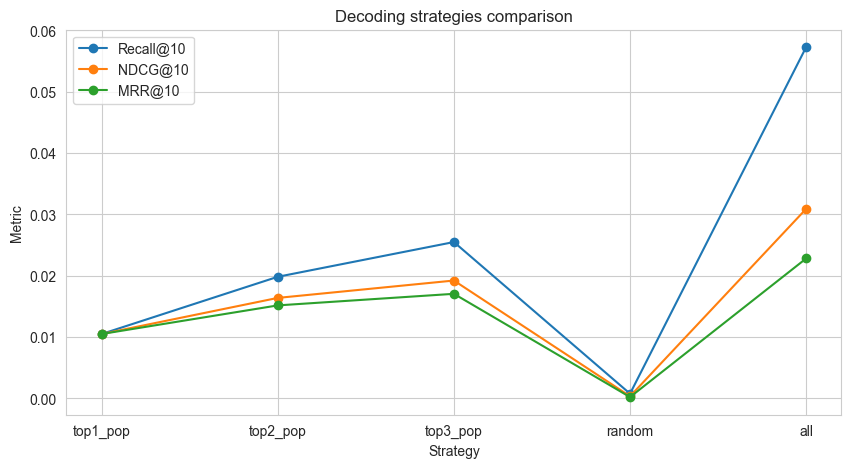

In [58]:
plt.figure(figsize=(10, 5))

for metric in [
    "Recall@10",
    "NDCG@10",
    "MRR@10",
]:
    plt.plot(
        decoding_table["strategy"],
        decoding_table[metric],
        marker="o",
        label=metric,
    )

plt.title("Decoding strategies comparison")
plt.xlabel("Strategy")
plt.ylabel("Metric")
plt.legend()
plt.grid(True)
plt.show()

In [61]:
comparison_plot = comparison_table.reset_index()
comparison_plot = comparison_plot.rename(
    columns={"index": "model"}
)

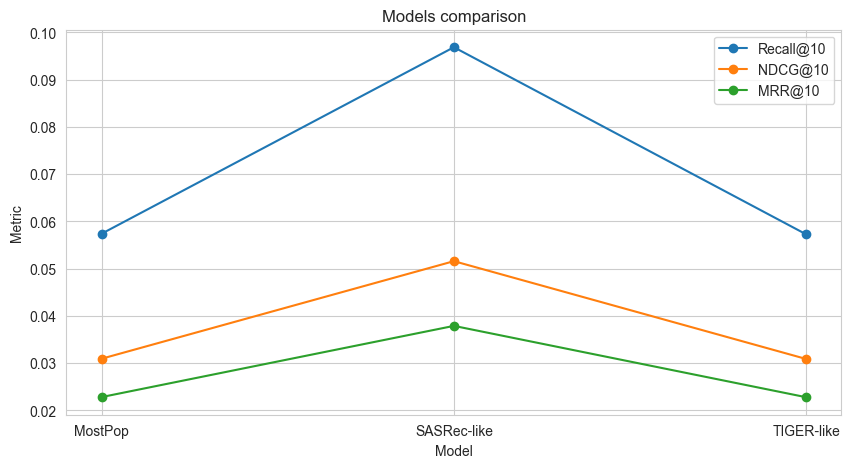

In [60]:
plt.figure(figsize=(10, 5))

for metric in comparison_plot.columns[1:]:
    plt.plot(
        comparison_plot["model"],
        comparison_plot[metric],
        marker="o",
        label=metric,
    )

plt.title("Models comparison")
plt.xlabel("Model")
plt.ylabel("Metric")
plt.legend()
plt.grid(True)
plt.show()

### Отчет по работе

На этапе построения semantic ids RQ-VAE успешно научился восстанавливать контентные эмбеддинги айтемов: reconstruction loss быстро снизился и стабилизировался на низком уровне. Однако анализ полученных кодов показал крайне высокую степень коллизий. Для 13 919 айтемов было получено всего 34 уникальных semantic id без уникализирующего суффикса, а средний размер bucket-а составил более 400 объектов, при этом крупнейший bucket содержал свыше 11 тысяч айтемов. Это говорит о том, что модель научилась хорошо реконструировать признаки, но использовала кодовые книги неэффективно и сформировала слишком грубое семантическое разбиение каталога.

Наилучший результат показал SASRec-like. Это ожидаемо, поскольку модель обучается непосредственно на последовательностях реальных айтемов и не теряет информацию при переходе к semantic ids. TIGER-like в данном эксперименте практически не превзошёл MostPop и показал очень близкие значения всех метрик. Основной причиной является низкое качество полученных semantic ids: из-за огромного числа коллизий модель фактически обучалась предсказывать очень небольшое количество семантических корзин вместо конкретных объектов каталога.

MostPop ожидаемо уступил SASRec-like, поскольку полностью игнорирует персональную историю пользователя. Однако интересно, что в данном эксперименте TIGER-like оказался практически на уровне MostPop. Это дополнительно подтверждает, что качество semantic ids является критически важным компонентом generative retrieval. Даже при наличии достаточно мощной последовательностной модели плохая дискретизация пространства айтемов ограничивает итоговое качество рекомендаций.

Также был проведён эксперимент без использования unique suffix. В этом случае несколько айтемов могли иметь один и тот же semantic id, а восстановление реального объекта выполнялось через различные стратегии декодирования bucket -> item.

Результаты показали заметную зависимость качества от выбранной стратегии декодинга. Наихудший результат продемонстрировала стратегия random, поскольку случайный выбор объекта внутри bucket-а практически разрушает полезный сигнал модели. Стратегии top2_pop и top3_pop показали лучшие результаты среди вариантов выбора одного или нескольких популярных объектов внутри bucket-а. Максимальное значение Recall@10 было достигнуто стратегией all, когда пользователю возвращались все объекты из соответствующего bucket-а, однако такой подход искусственно увеличивает полноту рекомендаций и плохо масштабируется на реальные системы из-за большого числа кандидатов.

Сравнение вариантов с unique suffix и без него показывает, что unique suffix необходим для однозначного соответствия semantic id и item_id. Без него система становится сильно чувствительной к процедуре декодирования и качеству кластеризации айтемов внутри semantic bucket-ов. При высокой доле коллизий итоговое качество начинает определяться не столько генеративной моделью, сколько выбранной стратегией восстановления реального объекта.

В целом эксперимент подтвердил основные идеи TIGER: качество генеративной рекомендательной системы напрямую зависит от качества semantic ids. При хорошем семантическом кодировании generative retrieval способен эффективно работать без полного перебора каталога. Однако при большом количестве коллизий и слабом использовании кодовых книг преимущества подхода практически исчезают, а качество рекомендаций становится сопоставимым с простыми базовыми методами. В данном эксперименте основным ограничением оказалась именно стадия построения semantic ids.